# Differentiation

In [1]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')


def parse_params(folder_name):
    """
    Example:
    n_10_rq_1_v0_1 -> {"n": 10, "rq": 1, "v0": 1}
    """
    parts = folder_name.split("_")
    params = {}

    for i in range(0, len(parts) - 1, 2):
        key = parts[i]
        val = parts[i + 1]

        try:
            params[key] = float(val)
        except ValueError:
            params[key] = val
            pass

    return params


def analyze_h5(h5_path):
    with h5py.File(h5_path, "r") as f:
        psi = f["solution/psi_hist"][-1]
        qx = f["solution/qx_hist"][-1]
        qy = f["solution/qy_hist"][-1]

    qmag = np.sqrt(qx**2 + qy**2)

    area_psi = np.mean(0.5 * (np.clip(psi, -1, 1) + 1))
    area_q = np.mean(qmag)

    return {
        "area_psi": area_psi,
        "area_q": area_q,
        "max_psi": np.max(psi),
        "has_diff": np.any(psi > 0.9),
    }


def scan(base_dir):
    rows = []

    for param_folder in sorted(os.listdir(base_dir)):
        param_dir = os.path.join(base_dir, param_folder)

        if not os.path.isdir(param_dir):
            continue

        params = parse_params(param_folder)

        for sim_folder in sorted(os.listdir(param_dir)):
            sim_dir = os.path.join(param_dir, sim_folder)

            if not os.path.isdir(sim_dir):
                continue

            h5_files = [f for f in os.listdir(sim_dir) if f.endswith(".h5")]
            if not h5_files:
                continue

            h5_path = os.path.join(sim_dir, h5_files[0])
            obs = analyze_h5(h5_path)

            row = {
                "param_folder": param_folder,
                "sim_folder": sim_folder,
                "h5_path": h5_path,
            }

            row.update(params)
            row.update(obs)
            rows.append(row)

    return pd.DataFrame(rows)


def plot_area_vs_nb(df, rq, v0, y="area_psi"):
    # Filter dataset
    df_sub = df[(df["rq"] == rq) & (df["v0"] == v0)]

    if df_sub.empty:
        raise ValueError("No data for given rq and v0")

    # Group by number of beads
    grouped = df_sub.groupby("nb")[y].mean()

    # fig, ax = plt.subplots(figsize=(5, 4))

    ax.plot(
        grouped.index,
        grouped.values,
        "o-", 
        label=f"rq={rq}, v0={v0}"
    )

    # return fig, ax



def plot_vs(df, xparam, y="area_psi"):
    grouped = df.groupby(xparam)[y]

    mean = grouped.mean()
    std = grouped.std()

    fig, ax = plt.subplots(figsize=(5, 4))

    ax.errorbar(
        mean.index,
        mean.values,
        yerr=std.values,
        fmt="o-",
        capsize=3,
    )

    ax.set_xlabel(xparam)
    ax.set_ylabel(y)
    ax.grid()
    ax.set_ylim(-0.1, 1.1)

    return fig, ax

,param_folder,sim_folder,h5_path,nb,rq,v0,area_psi,area_q,max_psi,has_diff
0,nb_100_rq_0.0_v0_0.0,sim_data_20260504_202756,outputs/homo_speed_rq_sweep/nb_100_rq_0.0_v0_0...,100.0,0.0,0.0,1.776357e-15,0.195497,-1.000000,False
1,nb_100_rq_0.0_v0_0.0,sim_data_20260504_202853,outputs/homo_speed_rq_sweep/nb_100_rq_0.0_v0_0...,100.0,0.0,0.0,1.776357e-15,0.196608,-1.000000,False
2,nb_100_rq_0.0_v0_0.0,sim_data_20260504_202949,outputs/homo_speed_rq_sweep/nb_100_rq_0.0_v0_0...,100.0,0.0,0.0,1.776357e-15,0.200020,-1.000000,False
3,nb_100_rq_0.0_v0_3.0,sim_data_20260504_203046,outputs/homo_speed_rq_sweep/nb_100_rq_0.0_v0_3...,100.0,0.0,3.0,5.219409e-02,0.264995,1.312015,True
4,nb_100_rq_0.0_v0_3.0,sim_data_20260504_203153,outputs/homo_speed_rq_sweep/nb_100_rq_0.0_v0_3...,100.0,0.0,3.0,2.040860e-02,0.223318,1.235875,True
...,...,...,...,...,...,...,...,...,...,...
158,nb_9_rq_1.0_v0_3.0,sim_data_20260504_153102,outputs/homo_speed_rq_sweep/nb_9_rq_1.0_v0_3.0...,9.0,1.0,3.0,1.985418e-15,0.001131,-1.000000,False
159,nb_9_rq_1.0_v0_3.0,sim_data_20260504_153214,outputs/homo_speed_rq_sweep/nb_9_rq_1.0_v0_3.0...,9.0,1.0,3.0,1.987607e-15,0.000929,-1.000000,False
160,nb_9_rq_1.0_v0_5.0,sim_data_20260504_153322,outputs/homo_speed_rq_sweep/nb_9_rq_1.0_v0_5.0...,9.0,1.0,5.0,3.338540e-15,0.001259,-1.000000,False
161,nb_9_rq_1.0_v0_5.0,sim_data_20260504_153517,outputs/homo_speed_rq_sweep/nb_9_rq_1.0_v0_5.0...,9.0,1.0,5.0,3.368223e-15,0.001545,-1.000000,False


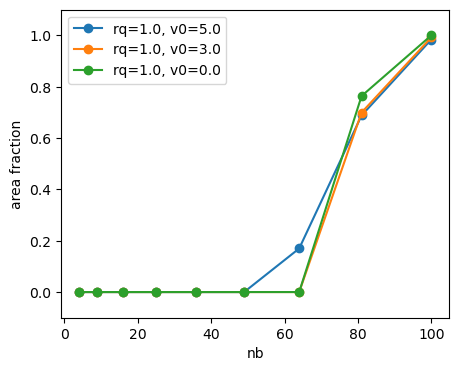

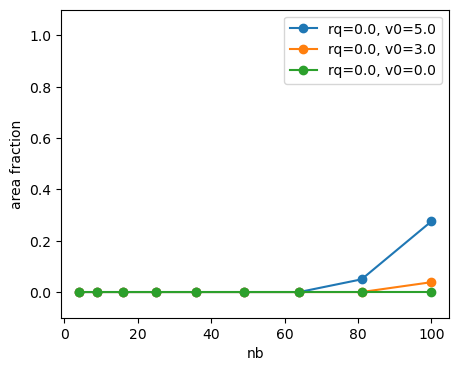

In [2]:
base_dir = "outputs/homo_speed_rq_sweep"

df = scan(base_dir)

display(df)

fig, ax = plt.subplots(figsize=(5, 4))

plot_area_vs_nb(df, rq=1.0, v0=5.0, y="area_psi")
plot_area_vs_nb(df, rq=1.0, v0=3.0, y="area_psi")
plot_area_vs_nb(df, rq=1.0, v0=0.0, y="area_psi")


ax.set_xlabel("nb")
ax.set_ylabel("area fraction")
ax.set_ylim(-0.1, 1.1)

plt.legend()
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))

plot_area_vs_nb(df, rq=0.0, v0=5.0, y="area_psi")
plot_area_vs_nb(df, rq=0.0, v0=3.0, y="area_psi")
plot_area_vs_nb(df, rq=0.0, v0=0.0, y="area_psi")

ax.set_xlabel("nb")
ax.set_ylabel("area fraction")
ax.set_ylim(-0.1, 1.1)

plt.legend()
plt.show()


,param_folder,sim_folder,h5_path,nb,rq,v0,area_psi,area_q,max_psi,has_diff
0,nb_100_rq_0.0_v0_0.0,sim_data_20260504_141931,outputs/pol_speed_rq_sweep/nb_100_rq_0.0_v0_0....,100.0,0.0,0.0,3.197557e-01,0.373462,1.000000,True
1,nb_100_rq_0.0_v0_0.0,sim_data_20260504_142029,outputs/pol_speed_rq_sweep/nb_100_rq_0.0_v0_0....,100.0,0.0,0.0,3.197557e-01,0.373485,1.000000,True
2,nb_100_rq_0.0_v0_0.0,sim_data_20260504_142127,outputs/pol_speed_rq_sweep/nb_100_rq_0.0_v0_0....,100.0,0.0,0.0,3.197557e-01,0.373561,1.000000,True
3,nb_100_rq_0.0_v0_3.0,sim_data_20260504_142224,outputs/pol_speed_rq_sweep/nb_100_rq_0.0_v0_3....,100.0,0.0,3.0,3.894352e-01,0.677119,1.299137,True
4,nb_100_rq_0.0_v0_3.0,sim_data_20260504_142332,outputs/pol_speed_rq_sweep/nb_100_rq_0.0_v0_3....,100.0,0.0,3.0,5.610252e-01,0.717788,1.293209,True
...,...,...,...,...,...,...,...,...,...,...
157,nb_9_rq_1.0_v0_3.0,sim_data_20260504_114716,outputs/pol_speed_rq_sweep/nb_9_rq_1.0_v0_3.0/...,9.0,1.0,3.0,1.634618e-15,0.004530,-1.000000,False
158,nb_9_rq_1.0_v0_3.0,sim_data_20260504_114831,outputs/pol_speed_rq_sweep/nb_9_rq_1.0_v0_3.0/...,9.0,1.0,3.0,1.545666e-15,0.005283,-1.000000,False
159,nb_9_rq_1.0_v0_5.0,sim_data_20260504_114942,outputs/pol_speed_rq_sweep/nb_9_rq_1.0_v0_5.0/...,9.0,1.0,5.0,3.111413e-15,0.004508,-1.000000,False
160,nb_9_rq_1.0_v0_5.0,sim_data_20260504_115139,outputs/pol_speed_rq_sweep/nb_9_rq_1.0_v0_5.0/...,9.0,1.0,5.0,2.915454e-15,0.005012,-1.000000,False


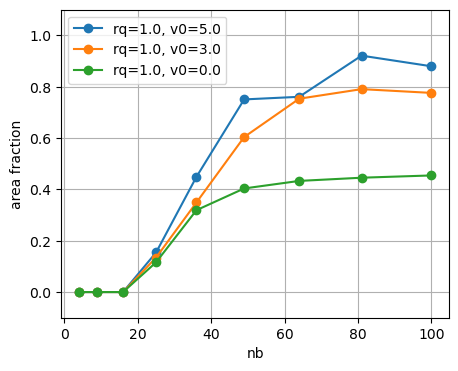

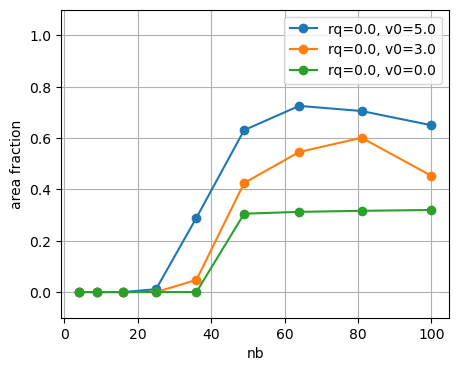

In [3]:
base_dir = "outputs/pol_speed_rq_sweep"

df = scan(base_dir)

display(df)

fig, ax = plt.subplots(figsize=(5, 4))

plot_area_vs_nb(df, rq=1.0, v0=5.0, y="area_psi")
plot_area_vs_nb(df, rq=1.0, v0=3.0, y="area_psi")
plot_area_vs_nb(df, rq=1.0, v0=0.0, y="area_psi")


ax.set_xlabel("nb")
ax.set_ylabel("area fraction")
ax.set_ylim(-0.1, 1.1)
ax.grid()
plt.legend()
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))

plot_area_vs_nb(df, rq=0.0, v0=5.0, y="area_psi")
plot_area_vs_nb(df, rq=0.0, v0=3.0, y="area_psi")
plot_area_vs_nb(df, rq=0.0, v0=0.0, y="area_psi")

ax.set_xlabel("nb")
ax.set_ylabel("area fraction")
ax.set_ylim(-0.1, 1.1)
ax.grid()
plt.legend()
plt.show()


# Beads no dynamics

In [34]:
base_dir = "outputs/bead_only_sweep"

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

df = scan(base_dir)

display(df)
df.to_csv(os.path.join(base_dir, "bead_only_sweep.csv"), index=False)

,param_folder,sim_folder,h5_path,dist,nb,rm,sigma,Dpsi,area_psi,area_q,max_psi,has_diff
0,dist_homo_nb_100_rm_0.1_sigma_0.1_Dpsi_0.001,sim_data_20260507_050151,outputs/bead_only_sweep/dist_homo_nb_100_rm_0....,homo,100.0,0.1,0.1,0.001,0.000149,1.535191e-07,-0.888294,False
1,dist_homo_nb_100_rm_0.1_sigma_0.1_Dpsi_0.1,sim_data_20260507_050155,outputs/bead_only_sweep/dist_homo_nb_100_rm_0....,homo,100.0,0.1,0.1,0.100,0.000142,1.311850e-07,-0.932773,False
2,dist_homo_nb_100_rm_0.1_sigma_0.1_Dpsi_1.0,sim_data_20260507_050159,outputs/bead_only_sweep/dist_homo_nb_100_rm_0....,homo,100.0,0.1,0.1,1.000,0.000140,1.213282e-07,-0.978341,False
3,dist_homo_nb_100_rm_0.1_sigma_0.1_Dpsi_1.5,sim_data_20260507_050230,outputs/bead_only_sweep/dist_homo_nb_100_rm_0....,homo,100.0,0.1,0.1,1.500,0.000140,1.220842e-07,-0.983080,False
4,dist_homo_nb_100_rm_0.1_sigma_0.5_Dpsi_0.001,sim_data_20260507_050317,outputs/bead_only_sweep/dist_homo_nb_100_rm_0....,homo,100.0,0.1,0.5,0.001,0.002887,1.608124e-05,-0.887589,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1795,dist_pol_nb_9_rm_1.5_sigma_1.5_Dpsi_1.5,sim_data_20260507_064415,outputs/bead_only_sweep/dist_pol_nb_9_rm_1.5_s...,pol,9.0,1.5,1.5,1.500,0.066393,1.186838e-01,0.851204,False
1796,dist_pol_nb_9_rm_1.5_sigma_2.0_Dpsi_0.001,sim_data_20260507_064500,outputs/bead_only_sweep/dist_pol_nb_9_rm_1.5_s...,pol,9.0,1.5,2.0,0.001,0.127157,1.383286e-01,1.000000,True
1797,dist_pol_nb_9_rm_1.5_sigma_2.0_Dpsi_0.1,sim_data_20260507_064504,outputs/bead_only_sweep/dist_pol_nb_9_rm_1.5_s...,pol,9.0,1.5,2.0,0.100,0.219114,2.235303e-01,1.000000,True
1798,dist_pol_nb_9_rm_1.5_sigma_2.0_Dpsi_1.0,sim_data_20260507_064508,outputs/bead_only_sweep/dist_pol_nb_9_rm_1.5_s...,pol,9.0,1.5,2.0,1.000,0.342077,3.228391e-01,1.000000,True


In [32]:
def plot_phase_diagram_bead_only(df, d_psi, dist, sigma):
    """
    Phase diagram for bead_only_sweep data.

    X-axis: rm
    Y-axis: nb
    Color: average area_psi over repeated simulations
    Marker style: differentiated / non-differentiated based on average has_diff
    """

    d = df.copy()
    d = d[d["Dpsi"] == d_psi]
    d = d[d["dist"] == dist]
    d = d[d["sigma"] == sigma]

    if d.empty:
        raise ValueError("No data for this combination of Dpsi, dist and sigma")

    # Average over repeated simulations with same parameters
    dg = (
        d.groupby(["rm", "nb"], as_index=False)
         .agg(
             area_psi_mean=("area_psi", "mean"),
             has_diff_mean=("has_diff", "mean"),
             n_sims=("area_psi", "size"),
         )
    )

    # Consider differentiated if at least one simulation differentiated
    # Alternative: use dg["has_diff_mean"] >= 0.5
    dg["diff"] = dg["has_diff_mean"] > 0

    d_diff = dg[dg["diff"]]
    d_nodiff = dg[~dg["diff"]]

    fig, ax = plt.subplots(figsize=(8, 6))

    if len(d_nodiff) > 0:
        ax.scatter(
            d_nodiff["rm"],
            d_nodiff["nb"],
            s=100,
            marker="o",
            facecolors="none",
            edgecolors="gray",
            alpha=0.5,
            label="No differentiation",
        )

    if len(d_diff) > 0:
        scatter = ax.scatter(
            d_diff["rm"],
            d_diff["nb"],
            c=d_diff["area_psi_mean"],
            s=100,
            cmap="viridis",
            vmin=0,
            vmax=1,
            edgecolors="black",
            linewidth=0.5,
            label="Differentiated",
        )

        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label(r"Mean area fraction $\langle \psi \rangle$")

    ax.set_xlabel(r"$r_m$")
    ax.set_ylabel(r"$N_{bd}$")
    ax.set_title(
        rf"Phase diagram: $D_\psi$={d_psi}, dist={dist}, $\sigma$={sigma}"
    )
    ax.grid(alpha=0.3)
    ax.legend()

    return fig, ax

# Example usage:
# fig, ax = plot_phase_diagram_bead_only(df, d_psi=1.0, dist="homo", sigma=0.1)
# plt.show()


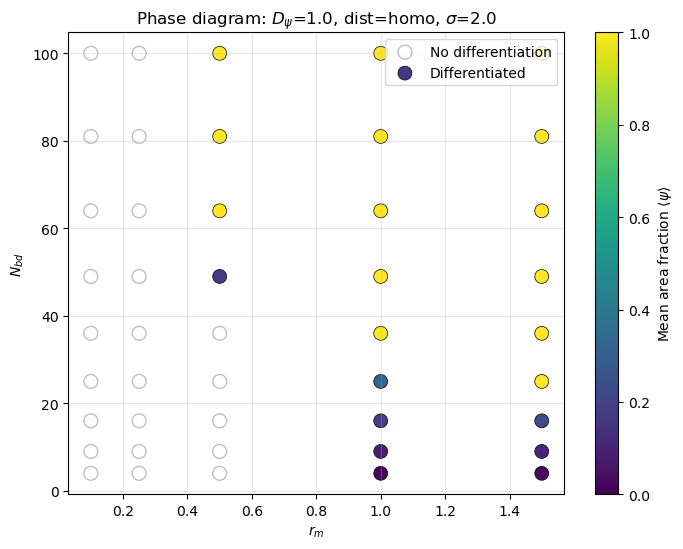

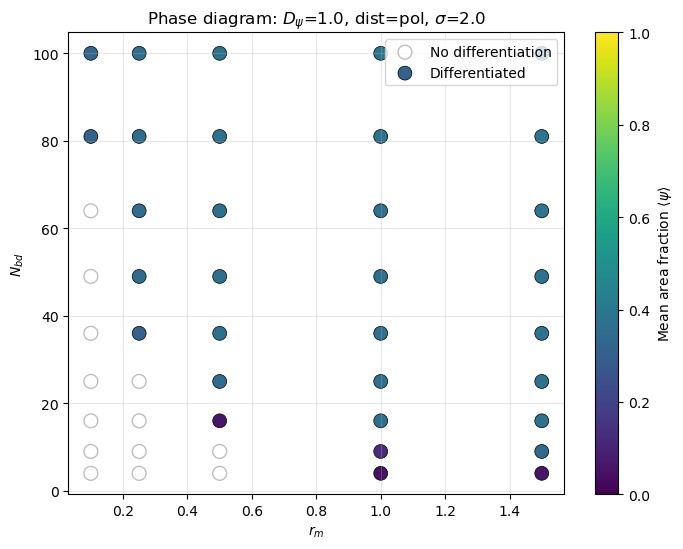

In [35]:
# Plot phase diagrams for different fixed parameter combinations
fig1, ax1 = plot_phase_diagram_bead_only(df, d_psi=1.0, dist="homo", sigma=2.0)
plt.show()


fig1, ax1 = plot_phase_diagram_bead_only(df, d_psi=1.0, dist="pol", sigma=2.0)
plt.show()


# Two beads

In [7]:
base_dir = "outputs/two_beads"

df = scan(base_dir)
display(df)

def plot_binary_phase_scatter(df, x, y, fixed=None):
    """
    Binary phase diagram using scatter points.

    diff = True  -> differentiated
    diff = False -> not differentiated
    """

    d = df.copy()

    # Apply fixed parameter filters
    if fixed is not None:
        for k, v in fixed.items():
            d = d[d[k] == v]

    if d.empty:
        raise ValueError("No data after filtering")

    # Separate differentiated / non differentiated
    d_true = d[d["has_diff"] == True]
    d_false = d[d["has_diff"] == False]

    fig, ax = plt.subplots(figsize=(5, 4))

    # Differentiated
    ax.scatter(
        d_true[x],
        d_true[y],
        marker="o",
        s=80,
        label="Differentiated"
    )

    # Non differentiated
    ax.scatter(
        d_false[x],
        d_false[y],
        marker="x",
        s=80,
        label="No differentiation"
    )

    ax.set_xlabel(x)
    ax.set_ylabel(y)

    if fixed is not None:
        title = ", ".join([f"{k}={v}" for k, v in fixed.items()])
        ax.set_title(title)

    ax.grid()
    # ax.legend()

    return fig, ax


def print_available_parameters(df):
    """
    Print unique values available for each parameter column.
    """

    # Columns you want to ignore
    ignore = {
        "param_folder",
        "sim_folder",
        "h5_path",
        "area_psi",
        "area_q",
        "max_psi",
        "has_diff",
        "diff",
    }

    # Candidate parameter columns
    param_cols = [c for c in df.columns if c not in ignore]

    print("=" * 50)

    for col in sorted(param_cols):

        # Remove NaNs and sort values
        vals = sorted(df[col].dropna().unique())

        print(f"{col}:")
        print(vals)
        print()

    print("=" * 50)

print_available_parameters(df)


,param_folder,sim_folder,h5_path,rm,sig,l,v0,alpha,rq,lamp,Dp,Dpsi,area_psi,area_q,max_psi,has_diff
0,rm_0.2_sig_0.5_l_0.5_v0_0.0_alpha_0.5_rq_0.0_l...,sim_data_20260518_113329,outputs/two_beads/rm_0.2_sig_0.5_l_0.5_v0_0.0_...,0.2,0.5,0.5,0.0,0.5,0.0,3.0,1.0,1.0,2.761412e-15,2.008822e-06,-1.000000,False
1,rm_0.2_sig_0.5_l_0.5_v0_0.0_alpha_0.5_rq_0.5_l...,sim_data_20260518_121731,outputs/two_beads/rm_0.2_sig_0.5_l_0.5_v0_0.0_...,0.2,0.5,0.5,0.0,0.5,0.5,3.0,1.0,1.0,2.763750e-15,1.520656e-06,-1.000000,False
2,rm_0.2_sig_0.5_l_0.5_v0_0.0_alpha_0.5_rq_1.0_l...,sim_data_20260518_130159,outputs/two_beads/rm_0.2_sig_0.5_l_0.5_v0_0.0_...,0.2,0.5,0.5,0.0,0.5,1.0,3.0,1.0,1.0,2.764058e-15,6.324730e-07,-1.000000,False
3,rm_0.2_sig_0.5_l_0.5_v0_3.0_alpha_0.5_rq_0.0_l...,sim_data_20260518_134626,outputs/two_beads/rm_0.2_sig_0.5_l_0.5_v0_3.0_...,0.2,0.5,0.5,3.0,0.5,0.0,3.0,1.0,1.0,3.778902e-15,6.928845e-07,-1.000000,False
4,rm_0.2_sig_0.5_l_0.5_v0_3.0_alpha_0.5_rq_0.5_l...,sim_data_20260518_143059,outputs/two_beads/rm_0.2_sig_0.5_l_0.5_v0_3.0_...,0.2,0.5,0.5,3.0,0.5,0.5,3.0,1.0,1.0,3.770991e-15,2.120981e-06,-1.000000,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427,rm_1.0_sig_2.0_l_5.0_v0_0.0_alpha_0.5_rq_0.5_l...,sim_data_20260518_125515,outputs/two_beads/rm_1.0_sig_2.0_l_5.0_v0_0.0_...,1.0,2.0,5.0,0.0,0.5,0.5,3.0,1.0,1.0,1.007061e-01,2.667286e-01,0.999953,True
428,rm_1.0_sig_2.0_l_5.0_v0_0.0_alpha_0.5_rq_1.0_l...,sim_data_20260518_133948,outputs/two_beads/rm_1.0_sig_2.0_l_5.0_v0_0.0_...,1.0,2.0,5.0,0.0,0.5,1.0,3.0,1.0,1.0,2.564019e-01,4.386573e-01,1.000000,True
429,rm_1.0_sig_2.0_l_5.0_v0_3.0_alpha_0.5_rq_0.0_l...,sim_data_20260518_142438,outputs/two_beads/rm_1.0_sig_2.0_l_5.0_v0_3.0_...,1.0,2.0,5.0,3.0,0.5,0.0,3.0,1.0,1.0,2.447751e-01,3.487435e-01,1.128361,True
430,rm_1.0_sig_2.0_l_5.0_v0_3.0_alpha_0.5_rq_0.5_l...,sim_data_20260518_150920,outputs/two_beads/rm_1.0_sig_2.0_l_5.0_v0_3.0_...,1.0,2.0,5.0,3.0,0.5,0.5,3.0,1.0,1.0,3.966063e-01,4.612195e-01,1.129720,True


Dp:
[np.float64(1.0)]

Dpsi:
[np.float64(1.0)]

alpha:
[np.float64(0.5)]

l:
[np.float64(0.5), np.float64(1.0), np.float64(2.0), np.float64(5.0), np.float64(10.0), np.float64(15.0)]

lamp:
[np.float64(3.0)]

rm:
[np.float64(0.2), np.float64(0.3), np.float64(0.5), np.float64(1.0)]

rq:
[np.float64(0.0), np.float64(0.5), np.float64(1.0)]

sig:
[np.float64(0.5), np.float64(1.0), np.float64(2.0)]

v0:
[np.float64(0.0), np.float64(3.0)]



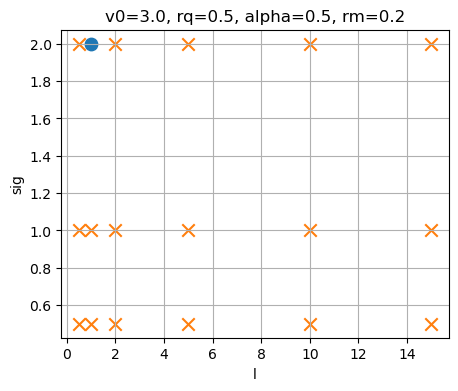

In [8]:
plot_binary_phase_scatter(
    df,
    x="l",
    y="sig",
    fixed={
        "v0": 3.0,
        "rq": 0.5,
        "alpha": 0.5, 
        "rm": 0.2
    }
)

plt.show()

# Random position beads

In [36]:
base_dir = "outputs/bead_only_rand"

df = scan(base_dir)

display(df)
df.to_csv(os.path.join(base_dir, "bead_only_rand.csv"), index=False)

print_available_parameters(df)


,param_folder,sim_folder,h5_path,dist,nb,rm,sigma,Dpsi,area_psi,area_q,max_psi,has_diff
0,dist_homo_nb_100_rm_0.1_sigma_0.1_Dpsi_1.0,sim_data_20260527_173350,outputs/bead_only_rand/dist_homo_nb_100_rm_0.1...,homo,100.0,0.1,0.1,1.0,0.000121,0.0,-0.989372,False
1,dist_homo_nb_100_rm_0.1_sigma_0.1_Dpsi_1.0,sim_data_20260527_182640,outputs/bead_only_rand/dist_homo_nb_100_rm_0.1...,homo,100.0,0.1,0.1,1.0,0.000114,0.0,-0.989523,False
2,dist_homo_nb_100_rm_0.1_sigma_0.1_Dpsi_1.0,sim_data_20260527_191929,outputs/bead_only_rand/dist_homo_nb_100_rm_0.1...,homo,100.0,0.1,0.1,1.0,0.000121,0.0,-0.988987,False
3,dist_homo_nb_100_rm_0.1_sigma_0.1_Dpsi_1.0,sim_data_20260527_201224,outputs/bead_only_rand/dist_homo_nb_100_rm_0.1...,homo,100.0,0.1,0.1,1.0,0.000136,0.0,-0.989354,False
4,dist_homo_nb_100_rm_0.1_sigma_0.1_Dpsi_1.0,sim_data_20260527_210516,outputs/bead_only_rand/dist_homo_nb_100_rm_0.1...,homo,100.0,0.1,0.1,1.0,0.000129,0.0,-0.989152,False
...,...,...,...,...,...,...,...,...,...,...,...,...
2495,dist_pol_nb_9_rm_1.5_sigma_2.0_Dpsi_1.0,sim_data_20260527_174505,outputs/bead_only_rand/dist_pol_nb_9_rm_1.5_si...,pol,9.0,1.5,2.0,1.0,0.316229,0.0,1.000000,True
2496,dist_pol_nb_9_rm_1.5_sigma_2.0_Dpsi_1.0,sim_data_20260527_183752,outputs/bead_only_rand/dist_pol_nb_9_rm_1.5_si...,pol,9.0,1.5,2.0,1.0,0.246851,0.0,1.000000,True
2497,dist_pol_nb_9_rm_1.5_sigma_2.0_Dpsi_1.0,sim_data_20260527_193039,outputs/bead_only_rand/dist_pol_nb_9_rm_1.5_si...,pol,9.0,1.5,2.0,1.0,0.257926,0.0,1.000000,True
2498,dist_pol_nb_9_rm_1.5_sigma_2.0_Dpsi_1.0,sim_data_20260527_202336,outputs/bead_only_rand/dist_pol_nb_9_rm_1.5_si...,pol,9.0,1.5,2.0,1.0,0.255760,0.0,1.000000,True


Dpsi:
[np.float64(1.0)]

dist:
['homo', 'pol']

nb:
[np.float64(1.0), np.float64(4.0), np.float64(9.0), np.float64(16.0), np.float64(25.0), np.float64(36.0), np.float64(49.0), np.float64(64.0), np.float64(81.0), np.float64(100.0)]

rm:
[np.float64(0.1), np.float64(0.25), np.float64(0.5), np.float64(1.0), np.float64(1.5)]

sigma:
[np.float64(0.1), np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0)]



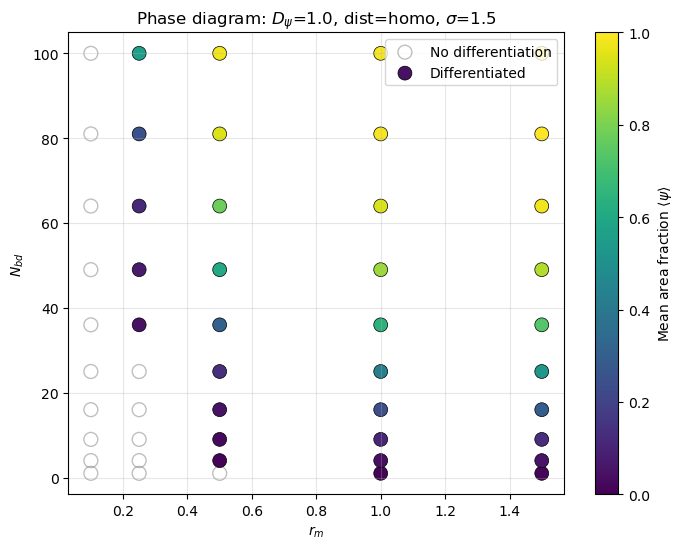

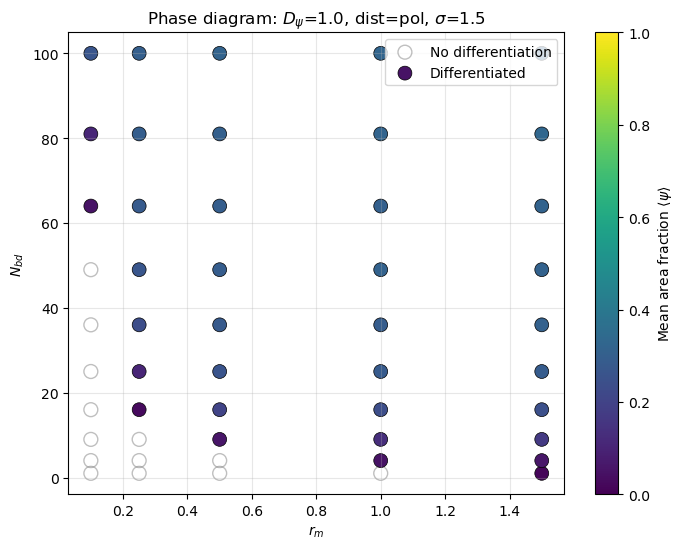

In [39]:
fig1, ax1 = plot_phase_diagram_bead_only(df, d_psi=1.0, dist="homo", sigma=1.5)
plt.show()


fig1, ax1 = plot_phase_diagram_bead_only(df, d_psi=1.0, dist="pol", sigma=1.5)
plt.show()

# Dynamics sweep lattice beads

In [9]:
base_dir = "outputs/dynamics_sweep"

df = scan(base_dir)
display(df)

print_available_parameters(df)

def plot_vs_fixed(df, xparam, fixed=None, y="area_psi", ax=None):
    """
    Plot mean y versus xparam, fixing arbitrary parameters.

    Example:
    plot_vs_fixed(df, "nb", fixed={"rq": 1.0, "v0": 3.0})
    """

    if fixed is None:
        fixed = {}

    df_sub = df.copy()

    for key, value in fixed.items():
        df_sub = df_sub[df_sub[key] == value]

    if df_sub.empty:
        raise ValueError(f"No data for fixed parameters: {fixed}")

    grouped = df_sub.groupby(xparam)[y].mean().sort_index()

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    else:
        fig = ax.figure

    label = ", ".join([f"{k}={v}" for k, v in fixed.items()])

    ax.plot(
        grouped.index,
        grouped.values,
        "o-",
        label=label
    )

    ax.set_xlabel(xparam)
    ax.set_ylabel(y)
    ax.legend()

    return fig, ax


,param_folder,sim_folder,h5_path,dist,n,v0,alpha,rq,lamp,Dp,area_psi,area_q,max_psi,has_diff
0,dist_homo_n_100_v0_0.5_alpha_0.1_rq_0.0_lamp_5...,sim_data_20260509_103912,outputs/dynamics_sweep/dist_homo_n_100_v0_0.5_...,homo,100.0,0.5,0.1,0.0,5.0,1.0,0.999514,0.964867,1.020408,True
1,dist_homo_n_100_v0_0.5_alpha_0.1_rq_0.0_lamp_5...,sim_data_20260509_113040,outputs/dynamics_sweep/dist_homo_n_100_v0_0.5_...,homo,100.0,0.5,0.1,0.0,5.0,1.0,0.999692,0.965193,1.024014,True
2,dist_homo_n_100_v0_0.5_alpha_0.1_rq_0.5_lamp_5...,sim_data_20260509_103926,outputs/dynamics_sweep/dist_homo_n_100_v0_0.5_...,homo,100.0,0.5,0.1,0.5,5.0,1.0,0.999606,0.964924,1.019492,True
3,dist_homo_n_100_v0_0.5_alpha_0.1_rq_0.5_lamp_5...,sim_data_20260509_113045,outputs/dynamics_sweep/dist_homo_n_100_v0_0.5_...,homo,100.0,0.5,0.1,0.5,5.0,1.0,0.999915,0.965286,1.027353,True
4,dist_homo_n_100_v0_0.5_alpha_0.1_rq_1.0_lamp_5...,sim_data_20260509_103927,outputs/dynamics_sweep/dist_homo_n_100_v0_0.5_...,homo,100.0,0.5,0.1,1.0,5.0,1.0,0.999813,0.965166,1.027071,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
967,dist_pol_n_9_v0_3.0_alpha_1.0_rq_0.0_lamp_5.0_...,sim_data_20260509_113716,outputs/dynamics_sweep/dist_pol_n_9_v0_3.0_alp...,pol,9.0,3.0,1.0,0.0,5.0,1.0,0.063698,0.211885,1.144143,True
968,dist_pol_n_9_v0_3.0_alpha_1.0_rq_0.5_lamp_5.0_...,sim_data_20260509_104603,outputs/dynamics_sweep/dist_pol_n_9_v0_3.0_alp...,pol,9.0,3.0,1.0,0.5,5.0,1.0,0.925471,0.967873,1.147877,True
969,dist_pol_n_9_v0_3.0_alpha_1.0_rq_0.5_lamp_5.0_...,sim_data_20260509_113718,outputs/dynamics_sweep/dist_pol_n_9_v0_3.0_alp...,pol,9.0,3.0,1.0,0.5,5.0,1.0,0.818183,0.912426,1.177377,True
970,dist_pol_n_9_v0_3.0_alpha_1.0_rq_1.0_lamp_5.0_...,sim_data_20260509_104614,outputs/dynamics_sweep/dist_pol_n_9_v0_3.0_alp...,pol,9.0,3.0,1.0,1.0,5.0,1.0,0.629450,0.665333,1.133673,True


Dp:
[np.float64(1.0)]

alpha:
[np.float64(0.1), np.float64(0.5), np.float64(1.0)]

dist:
['homo', 'pol']

lamp:
[np.float64(5.0)]

n:
[np.float64(4.0), np.float64(9.0), np.float64(16.0), np.float64(25.0), np.float64(36.0), np.float64(49.0), np.float64(64.0), np.float64(81.0), np.float64(100.0)]

rq:
[np.float64(0.0), np.float64(0.5), np.float64(1.0)]

v0:
[np.float64(0.5), np.float64(1.0), np.float64(3.0)]



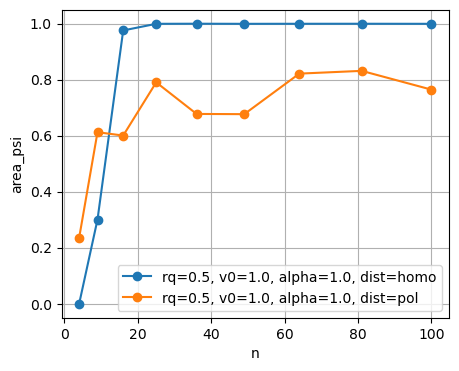

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))

fixed = {
        "rq": 0.5,
        "v0": 1.0,
        "alpha": 1.0, 
        "dist": "homo"}

plot_vs_fixed(
    df,
    xparam="n",
    y="area_psi",
    fixed=fixed, 
    ax=ax
)

fixed["dist"] = "pol"

plot_vs_fixed(
    df,
    xparam="n",
    y="area_psi",
    fixed=fixed, 
    ax=ax
)
plt.grid()
plt.show()